# Lesson 2 · Phase 1 — Text → Tokens → IDs → Embeddings

**Mastering Agentic AI Certification · Pre-read**

> A neural network cannot read letters — it only does **arithmetic on numbers**. So the very first job of any LLM is to turn text into numbers it can compute with. This phase follows one sentence through that pipeline, end to end.

## 1. The complete picture (this phase at a glance)

```
   "cats sleep"            raw text (what humans read)
        |   tokenize
        v
   ["cats", "sleep"]       TOKENS  (subword pieces)
        |   vocab lookup
        v
   [ 41 , 87 ]             TOKEN IDs (one integer per token)
        |   embedding lookup  (row of a learned matrix)
        v
   [[0.12, -0.4, 0.9, ...],     EMBEDDINGS (a dense vector per token)
    [0.55,  0.1,-0.3, ...]]     <- THIS is what the network actually computes on
```

**Text → Tokens → IDs → Embeddings.** Only the last form — vectors of floats — enters the neural network.

## 2. Step 1 · Text → Tokens

Models don't split on whole words (the vocabulary would be huge and miss rare/new words). They use **subword tokenization** (BPE, WordPiece, SentencePiece): common words stay whole, rare ones break into pieces.

```
"tokenization"  ->  ["token", "ization"]
"cats sleep"    ->  ["cats", "sleep"]
```

A **token** is just a chunk of text the model has a fixed slot for.

## 3. Step 2 · Tokens → IDs

Every token in the model's **vocabulary** has a unique integer **ID**. Tokenizing really means *looking up each piece in a dictionary* and emitting its number.

```
vocab = { ... "cats": 41, ... "sleep": 87, ... }
["cats", "sleep"]  ->  [41, 87]
```

IDs are just **addresses** — they carry no meaning yet. `41` is not "bigger" or "more" than `87`; they're labels.

## 4. Step 3 · IDs → Embeddings

This is the key step. The model holds an **embedding matrix** `E` of shape `(vocab_size, d_model)` — one **learned vector** per token ID. "Embedding" = *use the ID to pick a row*:

```
E[41]  ->  [0.12, -0.40, 0.90, ...]   # the vector that MEANS "cats"
E[87]  ->  [0.55,  0.10, -0.30, ...]  # the vector that MEANS "sleep"
```

Unlike the integer ID, an **embedding is a point in space whose direction encodes meaning**. These vectors are *parameters* — they start random and are **learned during pre-training**.

In [1]:
import numpy as np
np.random.seed(0)

# --- A toy vocabulary (token -> ID) ---
vocab = {"<pad>":0, "cats":41, "dogs":42, "kittens":43, "sleep":87, "run":88, "rocks":150}
id_of  = vocab
tok_of = {i:t for t,i in vocab.items()}

# --- A learned embedding matrix: one row (vector) per ID. d_model = 4 (tiny) ---
VOCAB_SIZE, D_MODEL = 200, 4
E = np.random.randn(VOCAB_SIZE, D_MODEL) * 0.5   # in a real LLM these are LEARNED

def encode(text):
    tokens = text.split()                 # (toy) Step 1: text -> tokens
    ids    = [id_of[t] for t in tokens]   #        Step 2: tokens -> IDs
    embeds = E[ids]                        #        Step 3: IDs -> embeddings (row lookup)
    return tokens, ids, embeds

tokens, ids, embeds = encode("cats sleep")
print("TEXT     :", "cats sleep")
print("TOKENS   :", tokens)
print("IDs      :", ids)
print("EMBEDDINGS (shape", embeds.shape, "):")
print(np.round(embeds, 2))

TEXT     : cats sleep
TOKENS   : ['cats', 'sleep']
IDs      : [41, 87]
EMBEDDINGS (shape (2, 4) ):
[[-0.61  0.42 -0.5  -0.77]
 [ 0.29  0.17 -0.38 -0.72]]


## 5. Why embeddings? Meaning becomes geometry

Because embeddings are learned, **similar tokens end up as nearby vectors**. "cats" and "kittens" point in similar directions; "rocks" points elsewhere. We measure closeness with **cosine similarity** (1 = same direction, 0 = unrelated).

The cell below *hand-places* a few vectors to show the idea (a trained model discovers this on its own).

In [2]:
# Hand-set a few embeddings so "meaning = geometry" is visible (training would learn this).
E[id_of["cats"]]    = [ 0.90,  0.10,  0.20, 0.0]
E[id_of["kittens"]] = [ 0.85,  0.15,  0.25, 0.0]   # close to cats
E[id_of["dogs"]]    = [ 0.70, -0.10,  0.30, 0.0]   # animal-ish
E[id_of["rocks"]]   = [-0.80,  0.60, -0.50, 0.0]   # far away

def cosine(a, b):
    return float(a @ b / (np.linalg.norm(a)*np.linalg.norm(b)))

for w in ["kittens", "dogs", "rocks"]:
    print(f"cos( cats , {w:<8} ) = {cosine(E[id_of['cats']], E[id_of[w]]): .3f}")
print("\n-> 'kittens' is closest to 'cats'; 'rocks' is far. Direction encodes meaning.")

cos( cats , kittens  ) =  0.996
cos( cats , dogs     ) =  0.955
cos( cats , rocks    ) = -0.733

-> 'kittens' is closest to 'cats'; 'rocks' is far. Direction encodes meaning.


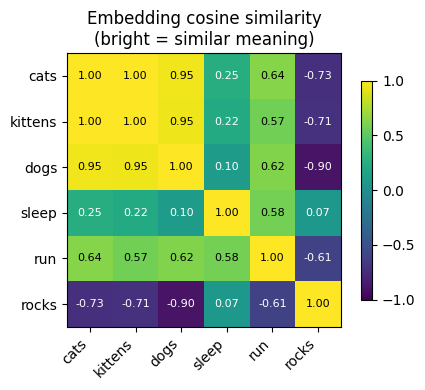

In [3]:
# COMPLETE PICTURE: a similarity heatmap of the toy vocabulary.
import numpy as np, matplotlib.pyplot as plt
words = ["cats","kittens","dogs","sleep","run","rocks"]
V = np.array([E[id_of[w]] for w in words])
V = V / np.linalg.norm(V, axis=1, keepdims=True)
S = V @ V.T   # cosine similarity matrix

fig, ax = plt.subplots(figsize=(5,4))
im = ax.imshow(S, cmap="viridis", vmin=-1, vmax=1)
ax.set_xticks(range(len(words))); ax.set_xticklabels(words, rotation=45, ha="right")
ax.set_yticks(range(len(words))); ax.set_yticklabels(words)
for i in range(len(words)):
    for j in range(len(words)):
        ax.text(j, i, f"{S[i,j]:.2f}", ha="center", va="center",
                color="white" if S[i,j]<0.5 else "black", fontsize=8)
ax.set_title("Embedding cosine similarity\n(bright = similar meaning)")
fig.colorbar(im, ax=ax, shrink=0.8); plt.tight_layout(); plt.show()

## 6. How this contributes downstream

These embedding **vectors are the input to the neural network**. Everything later — the neurons, layers, and predictions you'll see in **Phase 2** — operates on these floats, never on the original text.

```
text -> tokens -> IDs -> EMBEDDINGS ──▶ [ neural network layers ] ──▶ prediction
                          (Phase 1)              (Phase 2)
```

So embeddings are the **bridge** between human language and linear algebra. Get them wrong and nothing downstream can recover the meaning.

## 7. Key takeaways

1. Networks compute on **numbers**, so text must be converted first.
2. **Tokenize → look up IDs → look up embedding rows.** Only embeddings (float vectors) enter the network.
3. **IDs are arbitrary labels**; **embeddings are learned vectors where direction = meaning** (similar tokens → nearby vectors).
4. The **embedding matrix is a learned parameter**, trained during pre-training (Lesson 1).
5. These vectors are the **input** to the neurons/layers in **Phase 2**.

---
*Next (Phase 2):* how neurons, weights, and activations turn these embeddings into **predictions**.

In [4]:
import sys, platform
print("Python :", sys.version.split()[0]); print("Platform:", platform.platform())
print("Lesson 2 · Phase 1 (Text → Embeddings) notebook is running ✓")

Python : 3.12.11
Platform: Linux-6.12.76-linuxkit-x86_64-with-glibc2.36
Lesson 2 · Phase 1 (Text → Embeddings) notebook is running ✓
